### Objetivo deste Notebook
O objetivo deste notebook é explorar os padrões estatísticos das propriedades do solo e preparar o dataset para as etapas de modelagem, identificando distribuições, correlações e gradientes ambientais presentes nos dados.
Por meio de técnicas de análise exploratória de dados (EDA) e redução de dimensionalidade (PCA), busca-se compreender a estrutura multivariada do conjunto de dados e verificar quais variáveis contribuem mais para a variabilidade observada.

## Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import skew

## Carregar DataFrame

In [2]:
df_sample = pd.read_csv("df_sample_soilgrids.csv")

## Estatística descritiva

In [3]:
df_sample.describe()

,longitude,latitude,pH,SOC,Nitrogen,CTC,Clay,Sand,Silt,Bulk_Density
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,-47.814392,-18.949751,5.447710,28.494584,2.176111,131.828200,320.408560,473.257800,206.332140,1.252563
std,4.358451,2.995412,0.286242,11.120097,0.734061,37.880781,69.932791,108.407014,62.037742,0.085058
min,-54.998870,-24.998805,4.400000,12.500000,1.080000,67.000000,105.000000,85.000000,34.000000,0.530000
25%,-51.560610,-21.399848,5.300000,20.700000,1.630000,104.000000,275.000000,406.000000,159.000000,1.210000
50%,-48.070359,-18.797415,5.400000,25.100000,1.980000,121.000000,318.000000,474.000000,199.000000,1.270000
75%,-44.213902,-16.393330,5.600000,33.300000,2.530000,152.000000,363.000000,541.000000,246.000000,1.310000
max,-39.003391,-14.001195,7.200000,151.700000,7.790000,339.000000,667.000000,826.000000,569.000000,1.440000


Após ajuste das escalas, unidades usadas no estudo:                 
**Propriedades químicas**

- pH do solo                    
- Carbono Orgânico do Solo (SOC - g/kg)                 
- Nitrogênio Total (N total - g/kg)          
- Capacidade de Troca Catiônica (CTC - mmol(c)/kg)                    

**Propriedades físicas**         

- Teor de Argila (Clay - g/kg)          
- Teor de Areia (Sand - g/kg)        
- Teor de Silte (Silt - g/kg)            
- Densidade Aparente (Bulk Density – BD - g/cm³)     

## Distribuição das variáveis

### Avaliação da assimetria (skewness)

In [4]:
num_cols = df_sample.select_dtypes(include=[np.number]) \
                    .drop(columns=['latitude','longitude']) \
                    .columns

skew_table = pd.DataFrame({
    'Variável': num_cols,
    'Skewness': [skew(df_sample[col].dropna()) for col in num_cols]
})

skew_table['Classificação'] = pd.cut(
    skew_table['Skewness'].abs(),
    bins=[0, 0.5, 1, 2, np.inf],
    labels=['Leve', 'Moderada', 'Forte', 'Muito Forte']
)

skew_table.sort_values(by='Skewness', ascending=False)

,Variável,Skewness,Classificação
1,SOC,1.889880,Forte
2,Nitrogen,1.440871,Forte
3,CTC,1.227648,Forte
0,pH,0.775514,Moderada
6,Silt,0.583492,Moderada
4,Clay,0.358046,Leve
5,Sand,-0.143102,Leve
7,Bulk_Density,-1.195339,Forte


#### Insight
A análise de assimetria foi conduzida por meio do coeficiente de skewness, permitindo uma avaliação objetiva do comportamento estatístico das variáveis antes da modelagem.

As variáveis texturais (Clay, Sand e Silt) apresentaram valores de skewness próximos de zero, indicando comportamento equilibrado e estável. Dessa forma, não foi necessária nenhuma transformação adicional para essas variáveis.

Por outro lado, as variáveis químicas (SOC, Nitrogen e CTC) apresentaram valores de |skewness| superiores a 1, caracterizando forte assimetria. A variável Bulk Density também demonstrou assimetria relevante. Esse padrão indica presença de valores extremos com potencial de influenciar desproporcionalmente algoritmos baseados em distância, como o KMeans.

## Transformação das variáveis

### Aplicação de transformação logarítmica

In [5]:
# Variáveis automaticamente selecionadas por skew > 1
vars_auto = skew_table.loc[
    skew_table['Skewness'].abs() > 1, 'Variável'
].tolist()

# Garantir que Bulk_Density esteja incluída
vars_to_log = list(set(vars_auto + ['Bulk_Density']))

print("Variáveis que serão transformadas:")
print(vars_to_log)

Variáveis que serão transformadas:
['SOC', 'Nitrogen', 'CTC', 'Bulk_Density']


In [6]:
df_transformed = df_sample.copy()

for var in vars_to_log:
    
    if skew_table.loc[skew_table['Variável'] == var, 'Skewness'].values[0] < 0:
        # Reflexão para tratar skew negativo
        max_val = df_transformed[var].max()
        df_transformed[var] = np.log1p(max_val - df_transformed[var])
    else:
        df_transformed[var] = np.log1p(df_transformed[var])

### Comparação de skewness antes vs depois

In [7]:
print("Skewness antes e depois da transformação:\n")

for var in vars_to_log:
    skew_before = skew(df_sample[var].dropna())
    skew_after = skew(df_transformed[var].dropna())
    
    print(f"{var}")
    print(f"  Antes:  {skew_before:.2f}")
    print(f"  Depois: {skew_after:.2f}\n")

Skewness antes e depois da transformação:

SOC
  Antes:  1.89
  Depois: 0.80

Nitrogen
  Antes:  1.44
  Depois: 0.85

CTC
  Antes:  1.23
  Depois: 0.60

Bulk_Density
  Antes:  -1.20
  Depois: 0.93



#### Justificativa
Com base no critério objetivo de |skewness| > 1 como indicativo de forte assimetria, optou-se pela aplicação de transformação logarítmica (com reflexão no caso de assimetria negativa) antes da padronização. Essa etapa teve como finalidade reduzir a influência desproporcional de valores extremos na modelagem por métodos baseados em distância, como o KMeans, preservando ao mesmo tempo a estrutura relativa dos dados.

Após a transformação, todas as variáveis passaram a apresentar níveis de assimetria moderados (|skew| < 1), considerados adequados para a etapa de clusterização.

### Visualização antes vs depois

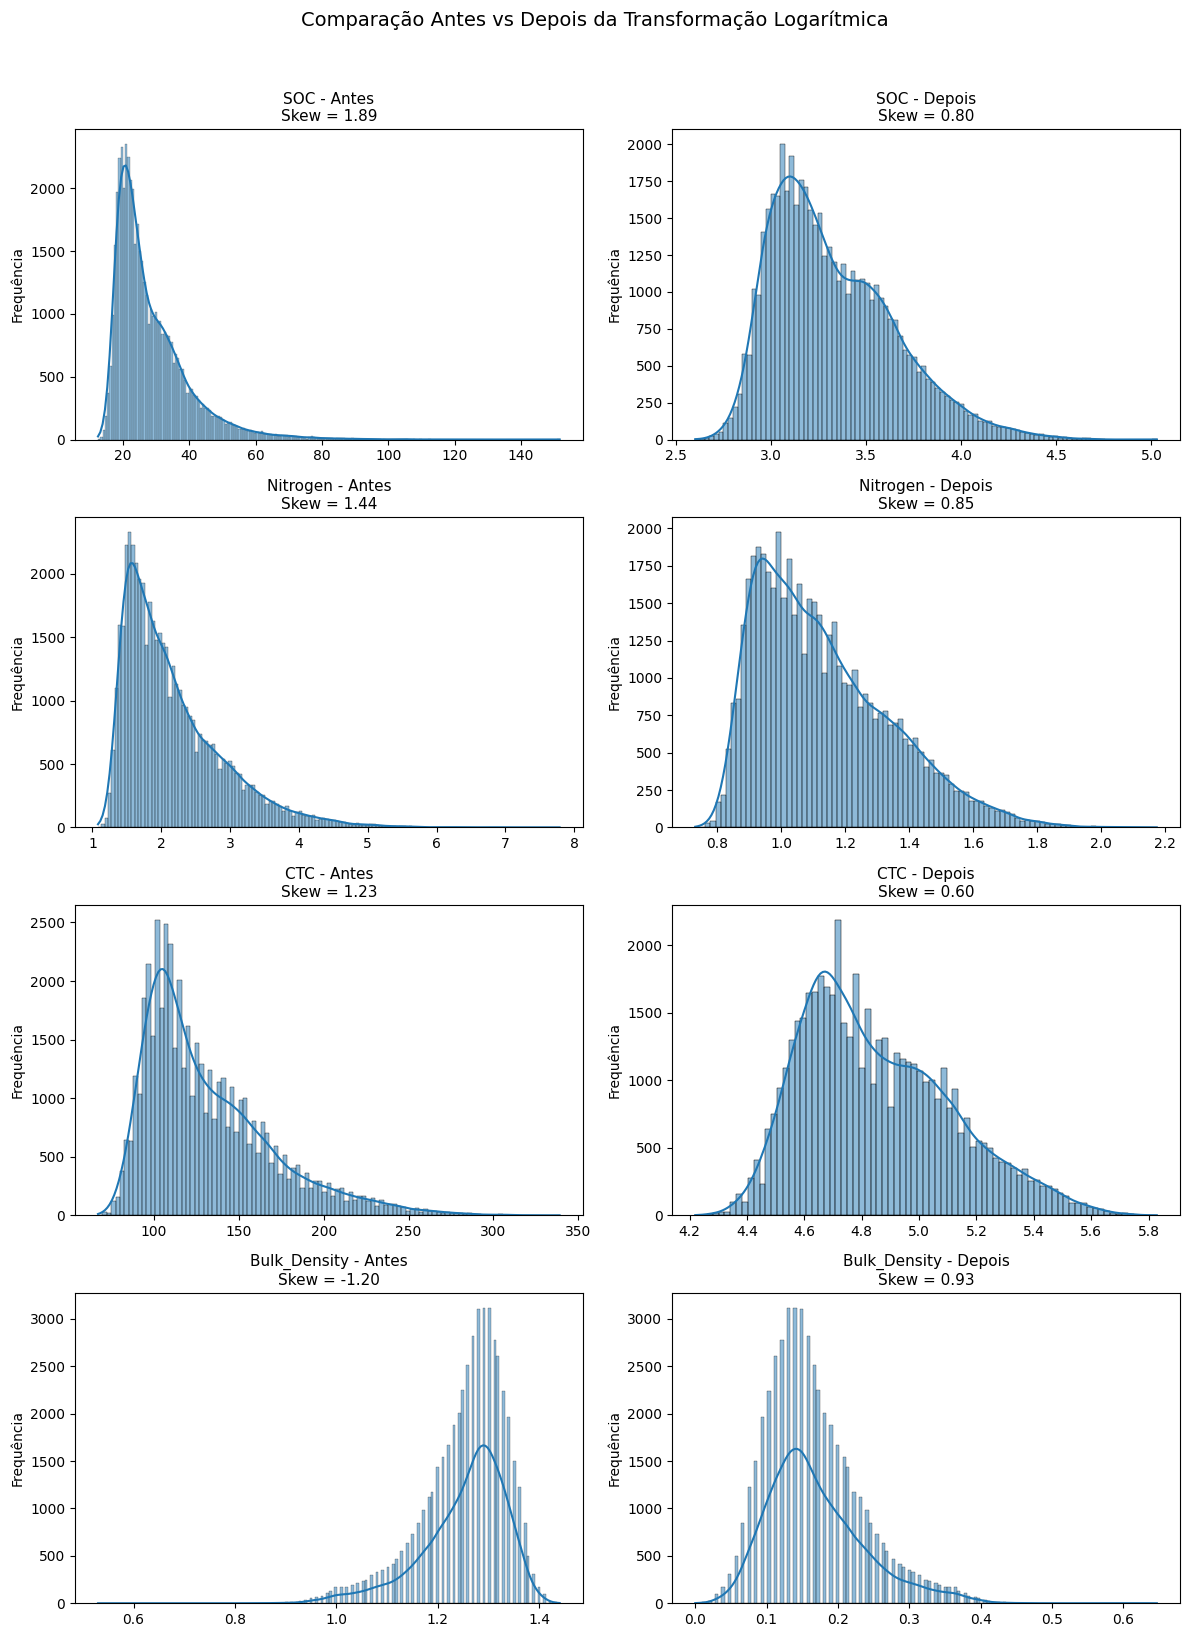

In [8]:
# Variáveis transformadas
vars_transformed = vars_to_log  # já definido anteriormente

fig, axes = plt.subplots(len(vars_transformed), 2, 
                         figsize=(12, 4*len(vars_transformed)))

for i, var in enumerate(vars_transformed):
    
    # --- Antes ---
    sns.histplot(
df_sample[var], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(
        f"{var} - Antes\nSkew = {skew(df_sample[var].dropna()):.2f}",
        fontsize=11
    )
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("Frequência")
    
    # --- Depois ---
    sns.histplot(df_transformed[var], kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(
        f"{var} - Depois\nSkew = {skew(df_transformed[var].dropna()):.2f}",
        fontsize=11
    )
    axes[i, 1].set_xlabel("")
    axes[i, 1].set_ylabel("Frequência")

plt.suptitle("Comparação Antes vs Depois da Transformação Logarítmica",
             fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

#### Conclusão
A visualização comparativa antes e depois da transformação confirma o diagnóstico quantitativo obtido via skewness. Observa-se redução clara das caudas longas, especialmente nas variáveis SOC, Nitrogen e CTC, indicando menor influência de valores extremos.

No caso da Bulk Density, a transformação reduziu a assimetria negativa acentuada, resultando em distribuição mais equilibrada e estatisticamente adequada para métodos baseados em distância.

De forma geral, as transformações cumpriram o objetivo de estabilizar as distribuições sem distorcer a estrutura dos dados, preparando o conjunto para a etapa de padronização e clusterização com maior robustez.

## Análise de correlação entre variáveis

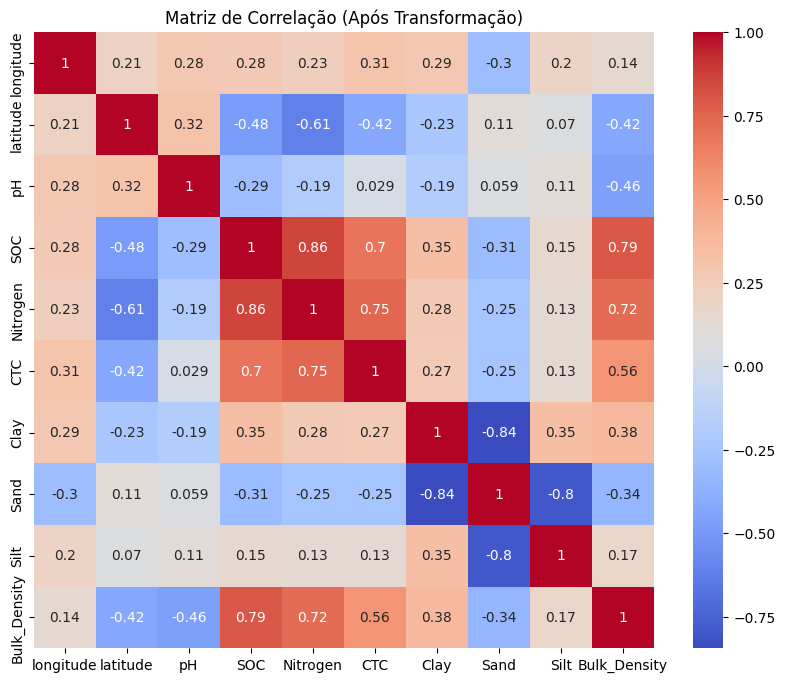

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df_transformed.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação (Após Transformação)")
plt.show()

#### Conclusão
A matriz de correlação revela uma estrutura organizada em dois eixos principais de variabilidade.
- O primeiro corresponde a um **gradiente químico**, com fortes correlações positivas entre SOC, Nitrogen e CTC, além de associação relevante com Bulk_Density. Esse padrão indica forte interdependência entre essas variáveis, sugerindo que elas refletem processos relacionados à fertilidade do solo e à dinâmica da matéria orgânica.                               
- O segundo eixo reflete um **gradiente textural**, evidenciado pelas fortes correlações negativas entre Sand e Clay/Silt, confirmando consistência física do sistema granulométrico.
      
Há ainda integração moderada entre textura e atributos químicos, sugerindo interação funcional entre propriedades físicas e químicas, além de indícios de influência espacial associados à latitude.                                               
Em síntese, os dados são estruturados principalmente pelos eixos químico e textural, que tendem a orientar a formação dos clusters, com possível contribuição do fator espacial.

## Padronização das variáveis

In [10]:
features = df_transformed[['Clay', 'Sand', 'Silt',
                           'SOC', 'Nitrogen', 'CTC',
                           'Bulk_Density']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

## Análise de componentes principais (PCA)

A aplicação do PCA neste estudo tem caráter diagnóstico e estrutural. Após a análise de correlação indicar a presença de dois blocos fortemente interdependentes — químico e textural — surge a necessidade de verificar se esses padrões realmente representam os principais eixos de variabilidade do conjunto de dados. Enquanto a correlação avalia relações par a par, o PCA permite analisar a estrutura multivariada global, identificando as direções que concentram maior variância.

Por meio dos componentes principais, é possível avaliar se os gradientes químico e textural emergem como eixos dominantes do sistema, além de quantificar a proporção da variância explicada por cada um. Essa etapa também permite avaliar o grau de correlação estrutural, especialmente no bloco químico, e compreender a complexidade real do dataset.

In [11]:
# Aplicação do PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [12]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.53637294 0.26007262]
0.7964455581724386


In [13]:
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

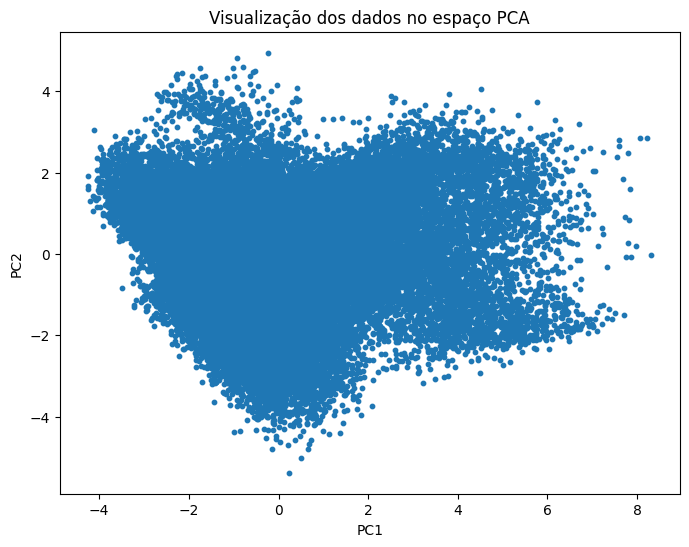

In [14]:
# Visualização PC1 vs PC2
plt.figure(figsize=(8,6))

plt.scatter(df_pca["PC1"], df_pca["PC2"], s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualização dos dados no espaço PCA")

plt.show()

#### Conclusão

Os dois primeiros componentes principais explicam aproximadamente 79,6% da variância total dos dados, permitindo uma representação bidimensional com perda reduzida de informação.

Esse resultado sugere a presença de dois gradientes estruturais dominantes: um associado às propriedades químicas do solo (SOC, Nitrogen e CTC), que apresenta maior contribuição para o primeiro componente, e outro relacionado à composição textural (Clay, Sand e Silt), com maior influência no segundo componente.

A projeção dos dados no espaço formado pelos dois primeiros componentes mostra uma distribuição contínua, característica comum em dados ambientais, com regiões de maior densidade que indicam possíveis estruturas ou concentrações de observações no espaço reduzido.

Esses resultados indicam que o dataset apresenta estrutura multivariada consistente, sendo adequado para a aplicação de técnicas de clusterização.

## Salvar dataset padronizado para modelagem

In [15]:
variables = ['Clay', 'Sand', 'Silt', 'SOC', 'Nitrogen', 'CTC', 'Bulk_Density']
X = df_sample[variables]
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [16]:
X_scaled_df.to_csv("soil_variables_scaled.csv", index=False)